# Comparing parallel universes - setpoint
If the user had their setpoint 1 degree lower, could they save money?

In [6]:
# Imports
import pandas as pd
import requests
from datetime import datetime, timezone, timedelta
from scipy.integrate import trapezoid

from model_helper_functions import get, plot_temp_power

In [7]:
# Set up API call
url = "https://bristol.passivuk.com/optimisation"
with open("API_key.txt", "r") as file:
    API_key = file.read()

## Compare two schedules

#### Research question 1:
If the user had their setpoint 1 degree lower, could they save money?

In [8]:
# Two schedules to compare
schedule_1_input = {
"num_zones": 1,
"zone_1_heating_daily_schedule": {"hours": [8, 10, 14, 16], "C": [21, 'frost', 21, 'frost']},
"start_datetime": "2024-01-01T07:00:00Z",
# "zone_1_temperature": 19 <- default
}

schedule_2_input = {
"num_zones": 1,
"zone_1_heating_daily_schedule": {"hours": [8, 10, 14, 16], "C": [20, 'frost', 20, 'frost']},
"start_datetime": "2024-01-01T07:00:00Z",
# "zone_1_temperature": 19 <- default
}

In [9]:
return_1 = requests.post(url, headers={"X-API-Key": API_key}, json=schedule_1_input).json()
return_2 = requests.post(url, headers={"X-API-Key": API_key}, json=schedule_2_input).json()

### Plot results

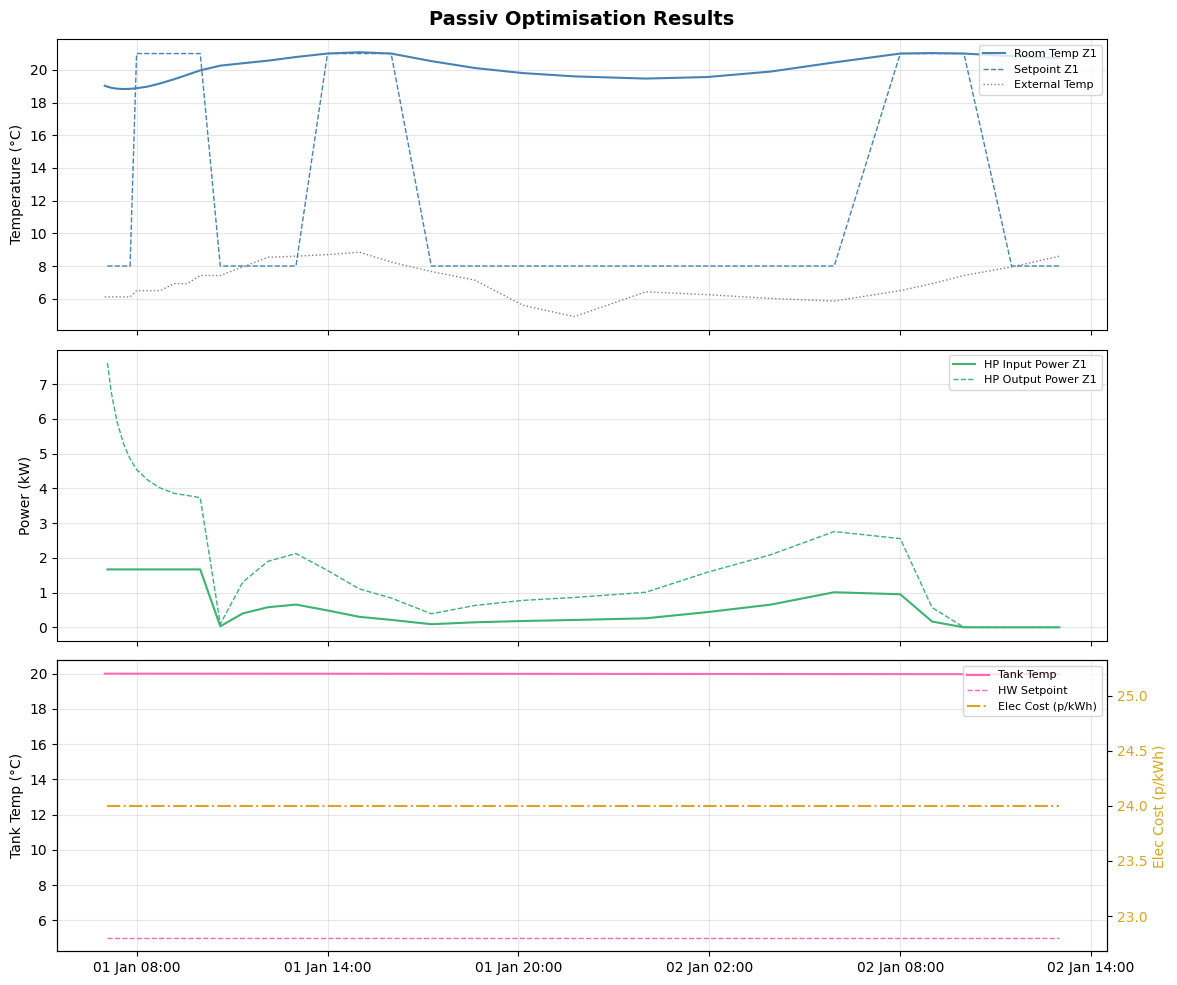

Data covers 30.0 hours (32 timesteps)


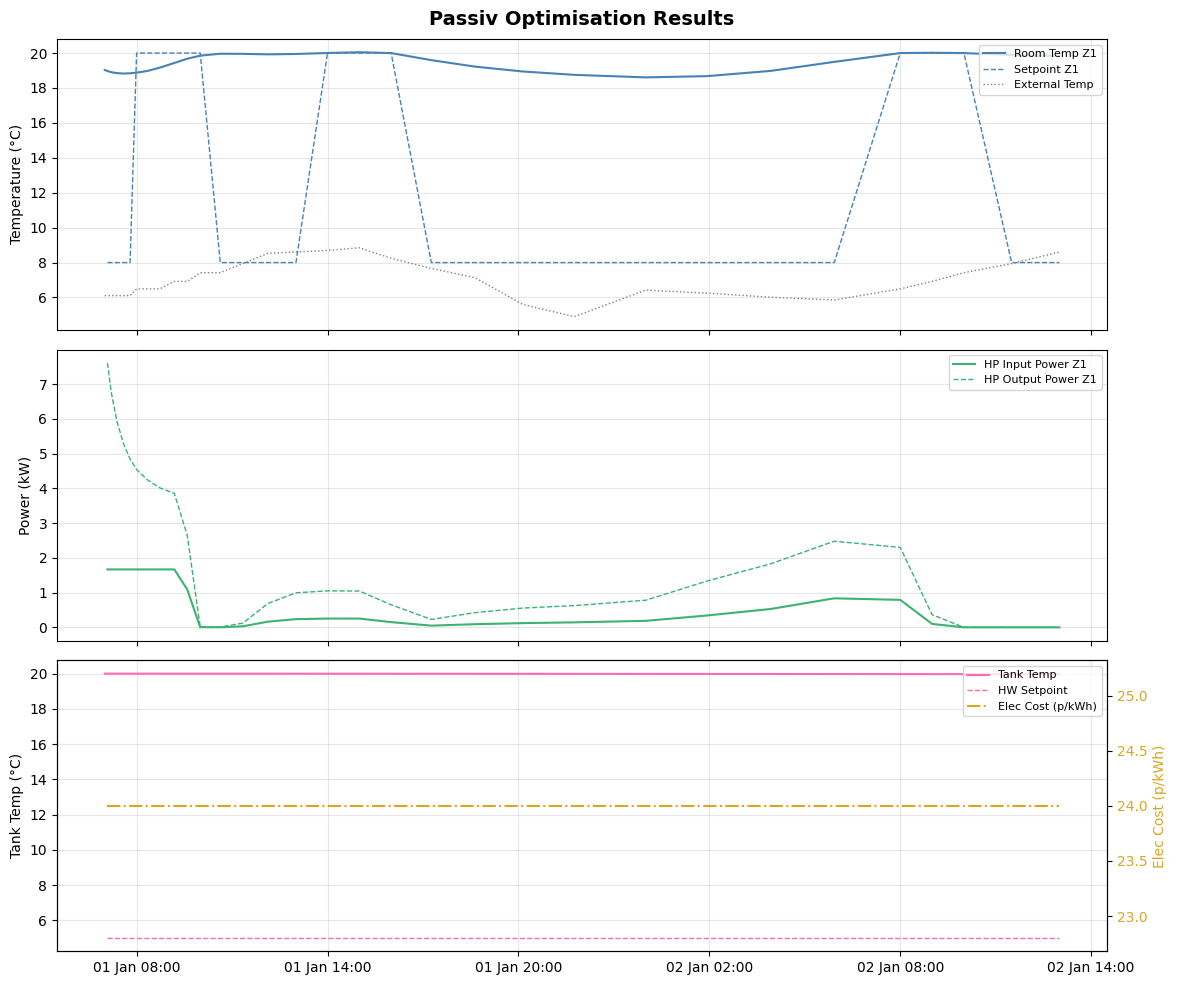

Data covers 30.0 hours (32 timesteps)


In [10]:
output_data = []
for outputs in [return_1, return_2]:
    if outputs['success']:
        dts = [datetime.fromisoformat(t.replace("Z", "+00:00")) for t in outputs["real_dt"]]
        n = len(dts)
        S = outputs["State"]
        df = pd.DataFrame({
            "Datetimes": dts,
            "Setpoint Z1": get(S, n, "setpoint.z1"),
            "Room Temp Z1": get(S, n, "room_temp.z1"),
            "External Temp": get(S, n, "ext"),
            "Input Power Z1": get(S, n, "E.hs1.heat.z1"),
            "Output Power Z1": get(S, n, "U.hs1.z1"),
            "Elec Cost (p/kWh)": get(S, n, "elec_cost"),
            "Tank Temp": get(S, n, "tank_temp"),
            "HW Setpoint": get(S, n, "setpoint_hw")
            # "Tariff":get(S, n, "tariff")
        })
        output_data.append(df)
        plot_temp_power(df, schedule_1_input.get("num_zones"))

### Calculate energy costs

In [11]:
def get_time_passed(df, start_time=datetime(year=2024, month=1, day=1, hour=0)):
    time_in_hours = []
    start_time = start_time.replace(tzinfo=timezone(timedelta(hours=0, minutes=0)))
    for time in df.Datetimes:
        time_elapsed = time-start_time  # Time deltas store time in days and seconds (for reasons....)
        time_in_hours.append(time_elapsed.days*24 + time_elapsed.seconds/(60*60))  # Time in hours since the start!
    return time_in_hours

In [12]:
for df in output_data:
        print("Total power used: ", round(sum(df["Input Power Z1"].dropna()), 2), " kW")
        power_df = df.copy(deep=True).dropna()
        time_in_hours = get_time_passed(power_df)
        if len(set(power_df["Elec Cost (p/kWh)"])) == 1:
                energy_used = trapezoid(power_df["Input Power Z1"], x=time_in_hours)
                print("Total energy used: ", round(energy_used, 2), " kWh")
                print("Energy cost: £", round(energy_used*df["Elec Cost (p/kWh)"][1]/100, 2))
        
        # else:
        #       need to go through dataframe
        #       integrate curve between times where energy cost values change
        #       calculate energy for each tariff + therefore cost for each chunk
        #       sum up to get total


Total power used:  25.11  kW
Total energy used:  15.25  kWh
Energy cost: £ 3.66
Total power used:  20.37  kW
Total energy used:  11.14  kWh
Energy cost: £ 2.67
